# **📊 RFM CUSTOMER SEGMENTATION ANALYSIS**

In [28]:
# Importing Libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Importing dataset:
df = pd.read_csv("customer_data.csv",encoding='latin1')
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [30]:
print(df.shape)
print(df.isnull().sum())
print("duplicates:",df.duplicated().sum())

(541909, 8)
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
duplicates: 5268


## **▢ DATA CLEANING:**

In [31]:
# Removing null records based on CustomerID:
df = df.dropna(subset = ["CustomerID"])
df.shape

# Changing dtype:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Cancelled orders:
print(df["InvoiceNo"].astype(str).str.startswith("C").sum())

# Handling nulls in description:
df["Description"] = df["Description"].fillna("Unknown")

# Dropping duplicate rows:
df = df.drop_duplicates(subset=['InvoiceNo','StockCode','Quantity','InvoiceDate','UnitPrice','CustomerID'])

# Dropping values with 0(Promotion,giveaways or samples)
df = df[df['UnitPrice'] > 0]

8905


In [32]:
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 401562 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401562 non-null  str           
 1   StockCode    401562 non-null  str           
 2   Description  401562 non-null  str           
 3   Quantity     401562 non-null  int64         
 4   InvoiceDate  401562 non-null  datetime64[us]
 5   UnitPrice    401562 non-null  float64       
 6   CustomerID   401562 non-null  float64       
 7   Country      401562 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.6 MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## **Cleanup Summary:**

### *1.I dropped all the null values from CustomerID column as a transaction cannot be assigned in RFM if we dont know the customer.Filled 'Unknown' in Description column where null found as it is of no use in RFM calculation.*
### *2.I checked for duplicates and initially suspected they were related to returns, but investigation showed they were exact repeated line items (same InvoiceNo, product, quantity, and price) — a data entry issue, not returns. These exact duplicates were removed."*
### *3.There are 8,905 records where InvoiceNo starts with 'C', indicating cancelled orders. These were kept rather than dropped, since their negative Quantity values naturally reduce a customer's Monetary total — giving a more accurate picture of their true net spend rather than inflating it with returned purchases.*
### *4.There are UnitPrice = 0, which is not possible unless it is some promotion, advertisement or sample.*

## **▢ RFM CALCULATION:**

In [33]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days = 1)

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x : (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [34]:
# Labelling R,F,M:

rfm["R_score"] = pd.qcut(rfm["Recency"],5,labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method='first'),5,labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"],5,labels=[1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
12346.0,326,2,0.00,1,2,1
12347.0,2,7,4310.00,5,4,5
12348.0,75,4,1797.24,2,3,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2


In [35]:
# Calculating RFM Score:

rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346.0,326,2,0.00,1,2,1,121
12347.0,2,7,4310.00,5,4,5,545
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [36]:
# Dividing in different Segments:

def customer_segment(row):
    if row["R_score"] >=4 and row["F_score"] >=4:
        return 'Champions'
    elif row["R_score"] >=3 and row["F_score"] >=3:
        return 'Loyal Customer'
    elif row["R_score"] >=4 and row["F_score"] <=2:
        return 'New Customer'
    elif row["R_score"] <=2 and row["F_score"] >=4:
        return 'At Risk'
    elif row["R_score"] <=2 and row["F_score"] <=2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm["Segment"] = rfm.apply(customer_segment, axis=1)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,2,1,121,Lost
12347.0,2,7,4310.00,5,4,5,545,Champions
12348.0,75,4,1797.24,2,3,4,234,Needs Attention
12349.0,19,1,1757.55,4,1,4,414,New Customer
12350.0,310,1,334.40,1,1,2,112,Lost


In [37]:
rfm["Segment"].value_counts()

Segment
Champions          1144
Lost               1058
Loyal Customer      801
Needs Attention     747
New Customer        329
At Risk             292
Name: count, dtype: int64

## **▢ EXPLONATORY DATA ANALYSIS:**

In [38]:
print("____________________________________________________________________________")
print("> Segment size as percentage:")
print(rfm["Segment"].value_counts(normalize=True) * 100)
print("____________________________________________________________________________")

print("> Avg R,F,M per segment:")
print(rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean())
print("____________________________________________________________________________")

print("> Total Monetary value by Segment:")
print(rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False))
print("____________________________________________________________________________")

print("> Top 5 Country with highest total Monetary-value:")
print(df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(5))
print("____________________________________________________________________________")

print("> Top 5 Country with Avg Monetary-value:")
print(df.groupby("Country")["TotalPrice"].mean().sort_values(ascending=False).head(5))

____________________________________________________________________________
> Segment size as percentage:
Segment
Champions          26.172501
Lost               24.204987
Loyal Customer     18.325326
Needs Attention    17.089911
New Customer        7.526882
At Risk             6.680394
Name: proportion, dtype: float64
____________________________________________________________________________
> Avg R,F,M per segment:
                    Recency  Frequency     Monetary
Segment                                            
At Risk          137.041096   5.910959  1671.122260
Champions         12.335664  12.098776  5024.571993
Lost             216.993384   1.202268   375.312468
Loyal Customer    36.443196   4.322097  1369.778216
Needs Attention  112.156627   1.925033   551.149226
New Customer      17.437690   1.358663   413.094529
____________________________________________________________________________
> Total Monetary value by Segment:
Segment
Champions          5748110.360
Loyal Cus

## **▢ VISUALISATION:**

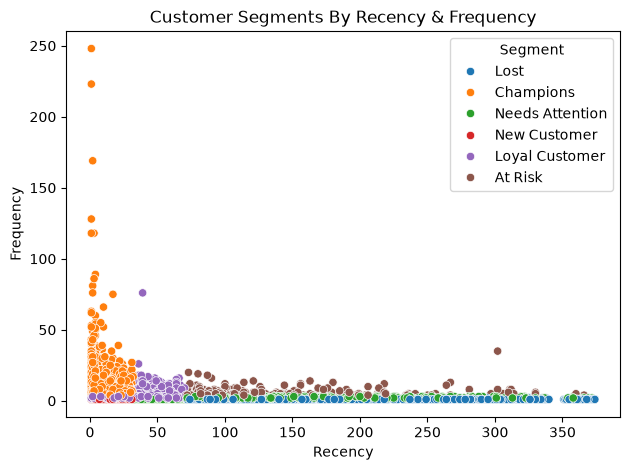

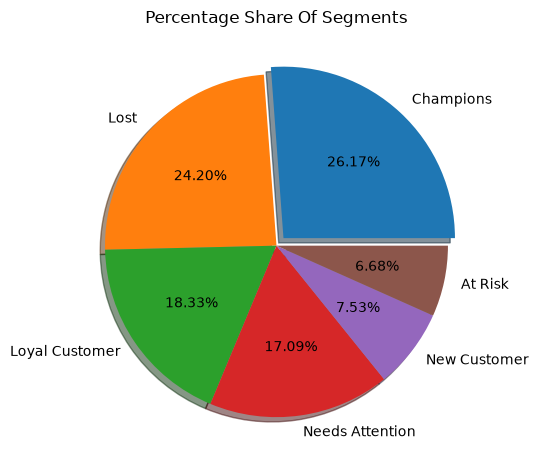

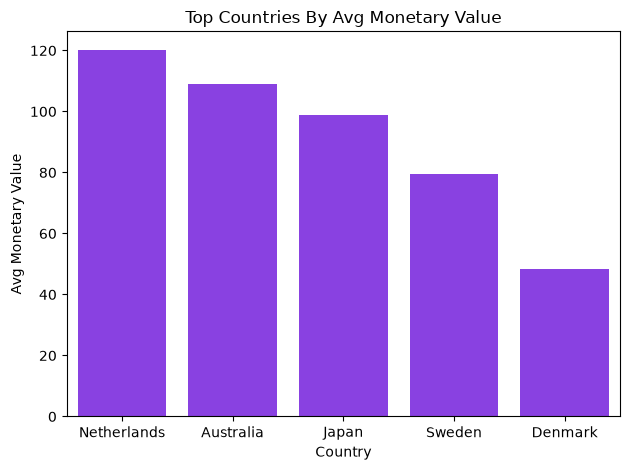

In [39]:
sns.scatterplot(x='Recency', y='Frequency', hue='Segment', data=rfm)
plt.title('Customer Segments By Recency & Frequency')
plt.tight_layout()
plt.show()

pie = rfm["Segment"].value_counts(normalize=True) * 100
plt.pie(x=pie.values, labels=pie.index, autopct='%1.2f%%',explode=[0.06,0,0,0,0,0],shadow=True)
plt.title("Percentage Share Of Segments")
plt.tight_layout()
plt.show()

bar = df.groupby("Country")["TotalPrice"].mean().sort_values(ascending=False).head()
sns.barplot(x=bar.index, y=bar.values, color='#8626fc')
plt.title("Top Countries By Avg Monetary Value")
plt.ylabel("Avg Monetary Value")
plt.tight_layout()
plt.show()

## **▢ IMPORTANT INSIGHTS:**
### *1.Champions & Lost customers hold nearly 50% of the Segment. Champion segment shows lower Recency, higher Frequency & Monetary value which is good as it holds around ~26% of the segment.Lost customer segment also hold around 24% of segment which is high.*
### *2.Loyal customers has the 2nd highest total Monetary value [1097192.351] after Champion customer segment, which shows it still contributes meaningfully to overall revenue.*
### *3.UK drives the highest total Monetary value overall - expected, since it is a UK-based retailer & most transactions originate there. While Netherlands has the highest Avg Monetary value, suggesting a number of high-spending customers here.*

## **▢ BUSINESS RECOMMENDATIONS:**

### *1.The Champions customer segment shows very impressive numbers overall, and to scale it further the business needs to keep the customers engage by providing discounts, rewards on purchase, cashbacks etc.*
### *2.The Lost segment holds a notable 24% share, but shows the weakest Recency, Frequency, and Monetary values across all groups. Rather than broad retention spend, the business should test a low-cost win-back campaign (e.g., a targeted discount email) on a small sample of this segment first — if response rates are poor, it validates deprioritizing further investment here; if not, it's a large pool of previously engaged customers worth re-activating..*
### *3.The Loyal customers adds a significant value in the business and hence more focus should be provided to them as they are already loyal, the business just have to maintain a good relation with them and scale this segment further.*
### *4.The Netherlands shows the highest average Monetary value per transaction, backed by a solid volume of 2,367 transactions (6th highest among all countries) — suggesting this isn't a fluke from a few big spenders, but a genuinely high-value market. Worth exploring further as a potential growth market, alongside the UK's dominant transaction volume.*

## **▢ LIMITATIONS:**
### *1.RFM looks backward, not forward — it shows what a customer has done, not what they'll do next, so segments can shift quickly and aren't a guarantee of future behavior.*
### *2.Segment thresholds (e.g., what counts as a "Champion") were manually defined — a reasonable framework, but not a fixed, universal rule.*
### *3.The dataset is heavily UK-concentrated, so country-level findings outside the UK are based on comparatively smaller samples and should be treated as directional, not definitive.*